In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree  import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [7]:
titanic = sns.load_dataset("titanic")

In [8]:
features = ["pclass","sex","fare","embarked","age"]
target=["survived"]

# missing data 
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [9]:
# encoded
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [10]:
X = titanic[features]
y = titanic["survived"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y ,test_size=0.2,random_state=42)

In [12]:
# decisiontree model no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train,y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("traning accuracy: ",accuracy_score(y_train,y_pred_train) * 100,"%")
print("testing accuracy: ",accuracy_score(y_test,y_pred_test) * 100,"%")


traning accuracy:  83.98876404494382 %
testing accuracy:  79.88826815642457 %


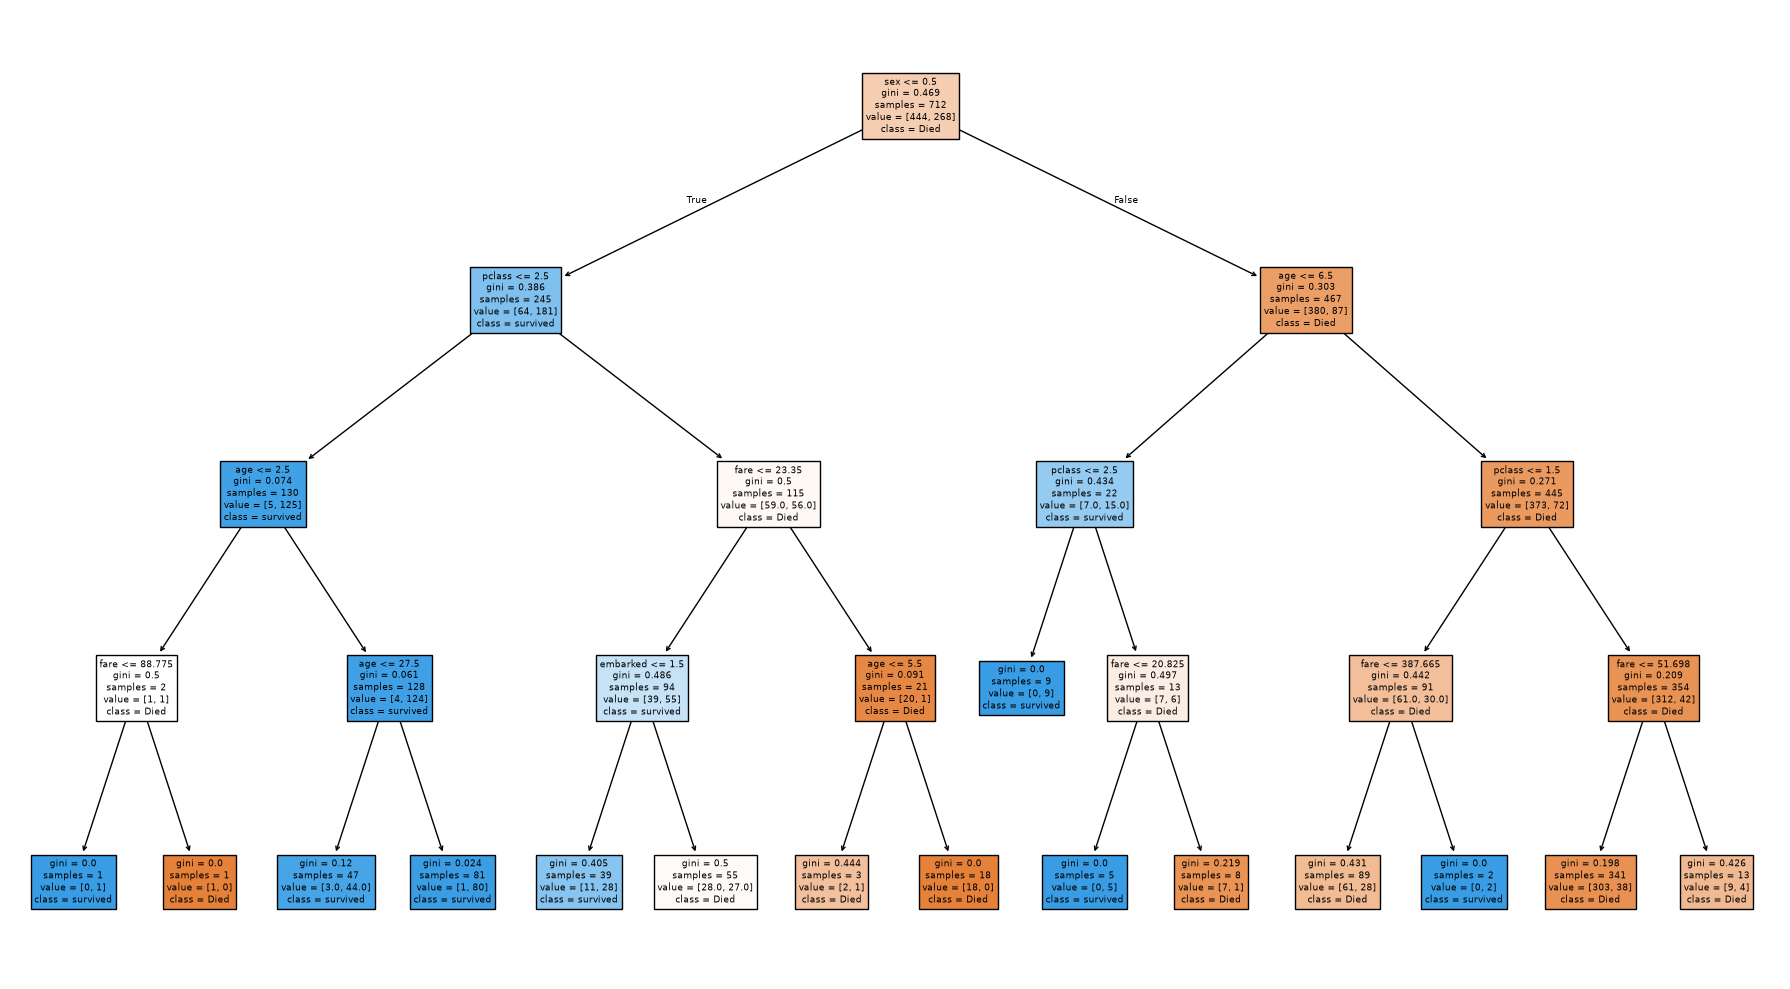

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
     model,
    feature_names=X.columns,
    class_names=["Died","survived"],
    filled=True,
    # max_depth=2
)

plt.tight_layout()
plt.show()

In [14]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=401,
    oob_score=True,
    max_depth=4
)
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

print("OOB score: ",rf.oob_score_ * 100, "%")
print("testing accuraacy: ",accuracy_score(y_test,y_pred) * 100,"%")



OOB score:  82.30337078651685 %
testing accuraacy:  82.12290502793296 %


In [16]:
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression(max_iter=1000)
bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ",accuracy_score(y_test,y_pred))

accuracy:  0.7988826815642458
